# Adding ion channel model into a passive compartment

## Set up a passive compartment along with instrumentation to inject current and record data

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import moose

# Import the channel model lib
import moose.channels as chan  


# Create a compartment called soma
soma = moose.Compartment('soma')

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [2]:
inject = moose.PulseGen('inject')
moose.connect(inject, 'output', soma, 'injectMsg')

inject_tab = moose.Table('inject_tab')
moose.connect(inject_tab, 'requestOut', inject, 'getOutputValue')

vm_tab = moose.Table('Vm_tab')
moose.connect(vm_tab, 'requestOut', soma, 'getVm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[2] id=5 dataIndex=2 fieldIndex=0>

## Using builtin channel models from the ICG database

MOOSE includes a plethora of Hodgkin-Huxley-type ion channels from the [Ion Channel Genealogy](https://icg.neurotheory.ox.ac.uk/) database.
The models are originally from [modeldb](https://modeldb.science) and you can select channels from the database by their unique ICG ID. If you do not know the ID, you can search the database by author, publication year, and ion class.

In [3]:
chan.search(author='Traub',  year=2005, ion_class='Na')


#    ModelDB ID   Year   Authors                             Channels
──────────────────────────────────────────────────────────────────────────────────────────
[0 ] 45539        2005   Traub RD, Contreras D,…             naf(Na), naf2(Na), naf_tcr(Na),…



[{'modeldb_id': 45539,
  'meta': {'icg_id': '2887',
   'modeldb_id': '45539',
   'suffix': 'ar',
   'ion_class': 'IH',
   'icg_ref_id': '343',
   'authors': 'Traub RD, Contreras D, Whittington MA',
   'title': 'Combined experimental/simulation studies of cellular and network mechanisms of epileptogenesis in vitro and in vivo.',
   'year': '2005',
   'pubmedid': '16357637',
   'citation_count': '32'},
  'channels': {'naf': [{'modeldb_id': 45539,
     'icg_id': '2905',
     'ion_class': 'Na',
     'suffix': 'naf',
     'gbar_name': 'gbar_naf',
     'gbar_default': 1.0,
     'q10_tau': 1.0,
     'q10_g': 1.0,
     'gate_var': 'm',
     'gate_power': 3,
     'best_sm': 5,
     'sm1_fit': True,
     'sm1_err1_ss': 0.0002780709691232326,
     'sm1_err1_tau': 0.18983561795229045,
     'sm2_fit': True,
     'sm2_err1_ss': 0.00022261926970913073,
     'sm2_err1_tau': 0.18983561795229045,
     'sm3_fit': True,
     'sm3_err1_ss': 0.0002780709691232412,
     'sm3_err1_tau': 0.35037321024991375,
 

### We can identify the ICG ID of our channels of interest either by scanning the printed data, or by looking at ICG database

We can then use `moose.channels.load([list of compartments], Gbar, Ek, icg_id={id})` function to directly insert the channel into the compartment.

In [4]:
naf_id = 2905
kdr_id = 2902

naf = chan.load([soma], icg_id=naf_id, gbar=4e-6, Ek=55.0)
kdr = chan.load([soma], icg_id=kdr_id, gbar=1e-6, Ek=-90.0)

print(naf)
print(kdr)

[<moose.HHChannel path=/soma[0]/naf_45539[0] id=499 dataIndex=0 fieldIndex=0>]
[<moose.HHChannel path=/soma[0]/kdr_45539[0] id=507 dataIndex=0 fieldIndex=0>]


Note that `chan.load()` returned a list of `HHChannel` objects, one inserted into each compartment in the compartment list. You can check the attributes of each using `moose.showfields()` functions

In [5]:
moose.showfield(naf[0])


[/soma[0]/naf_45539[0]]
name                 = naf_45539
className            = HHChannel
tick                 = 4
dt                   = 5e-05
Ek                   = 55.0
Gbar                 = 4e-06
Gk                   = 0.0
Ik                   = 0.0
X                    = 0.0
Xpower               = 3.0
Y                    = 0.0
Ypower               = 1.0
Z                    = 0.0
Zpower               = 0.0
instant              = 0
modulation           = 1.0
useConcentration     = 0



### We set the Rm and Cm of the compartment

In [6]:
soma.Rm = 1e4   # 10 kohm
soma.Cm = 100e-9 # 100 nF

### The stimulation configuration goes below

In [7]:
inject.delay[0] = 10e-3   # start the current pulse after 10 ms 
inject.width[0] = 15e-3   # the pulse width will be 15 ms
inject.level[0] = 1e-6   # pulse current amplitude will be 1 uA

## Initialize and run the simulation

In [8]:
moose.reinit()
moose.start(50e-3)

## Plot the response

Text(0.5, 0, 'Time (s)')

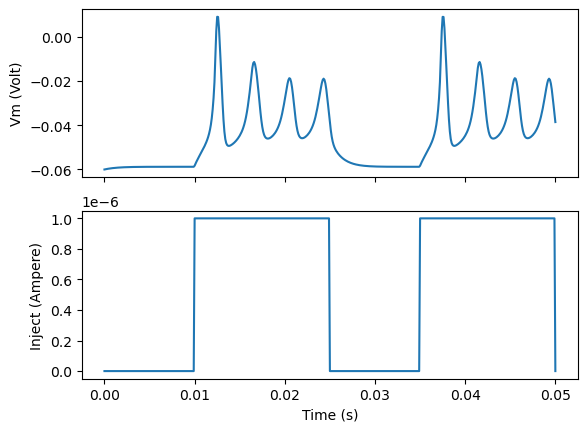

In [9]:
t = np.arange(len(vm_tab.vector)) * vm_tab.dt
fig, axes = plt.subplots(nrows=2, sharex='all')
axes[0].plot(t, vm_tab.vector)
axes[0].set_ylabel('Vm (Volt)')
axes[1].plot(t, inject_tab.vector)
axes[1].set_ylabel('Inject (Ampere)')
axes[1].set_xlabel('Time (s)')